In [4]:
import pandas as pd
import seaborn as sns
# from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt

In [5]:
# Load the California housing dataset
df = pd.read_csv("california_housing.csv")
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [6]:
column = "AveRooms"
# Calculate the first quartile (Q1) and third quartile (Q3)
q1 = df[column].quantile(0.25)
q3 = df[column].quantile(0.75)
# Calculate the interquartile range (IQR)
IQR = q3 - q1
# Calculate the lower and upper bounds for outliers
lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

print(f"Column: {column}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")

Column: AveRooms
IQR: 1.61
Lower Bound: 2.02
Upper Bound: 8.47


In [7]:
# Filter the DataFrame for outliers
outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
print(f"Number of outliers in {column}: {len(outliers)}")
print(f"Total number of rows in the dataset: {len(df)}")

Number of outliers in AveRooms: 511
Total number of rows in the dataset: 20640


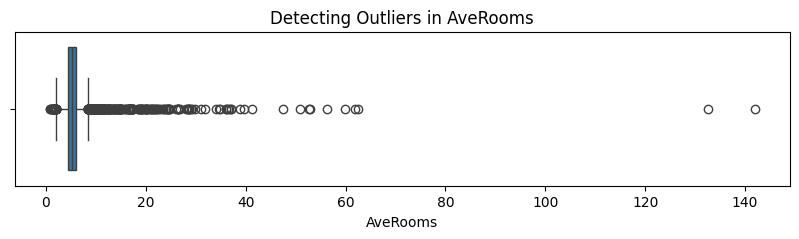

In [8]:
# visualize with boxplot
plt.figure(figsize=(10, 2)) # 10 inches wide and 2 inches tall
sns.boxplot(x=df[column])
plt.title(f"Detecting Outliers in {column}")
plt.show()

In [9]:
# Cleaning the dataset by removing outliers
cleaned_df = df[(df[column]>= lower_bound) & (df[column] <= upper_bound)]

print(f"Shape before cleaning: {df.shape}")
print(f"Shape after cleaning: {cleaned_df.shape}")

Shape before cleaning: (20640, 8)
Shape after cleaning: (20129, 8)


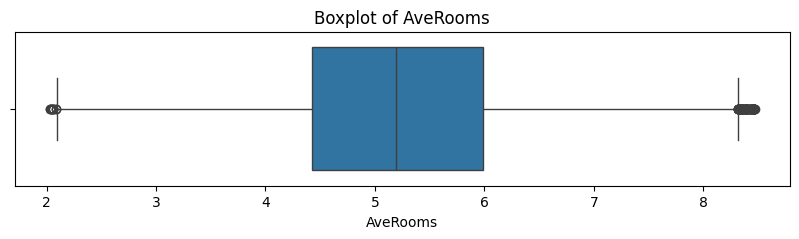

In [18]:
# visualizing the data after removing the outliers using boxplot

plt.figure(figsize=(10,2))
sns.boxplot(x = cleaned_df[column])
plt.title(f"Boxplot of {column}")
plt.show()

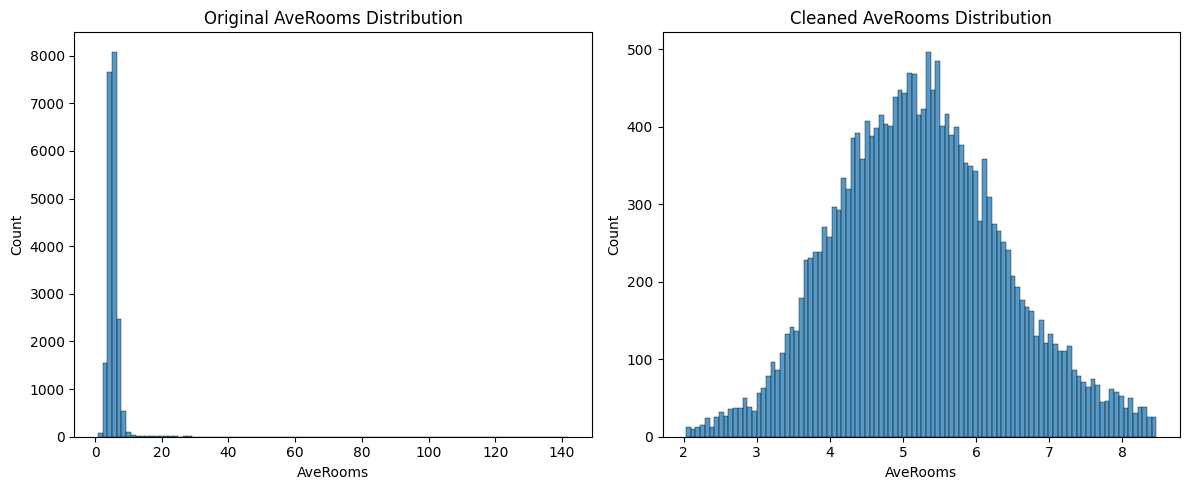

In [11]:
# compare the distribution of the original and cleaned datasets
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df[column], bins=100, ax=ax[0])
sns.histplot(cleaned_df[column], bins=100, ax=ax[1])
ax[0].set_title(f"Original {column} Distribution")
ax[1].set_title(f"Cleaned {column} Distribution")
plt.tight_layout()
plt.show()


In [12]:
new_column = "AveBedrms"
# Calculate the first quartile (Q1) and third quartile (Q3)
q1 = df[new_column].quantile(0.25)
q3 = df[new_column].quantile(0.75)
# Calculate the interquartile range (IQR)
IQR = q3 - q1
# Calculate the lower and upper bounds for outliers
lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

print(f"Column: {column}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")

Column: AveRooms
IQR: 0.09
Lower Bound: 0.87
Upper Bound: 1.24


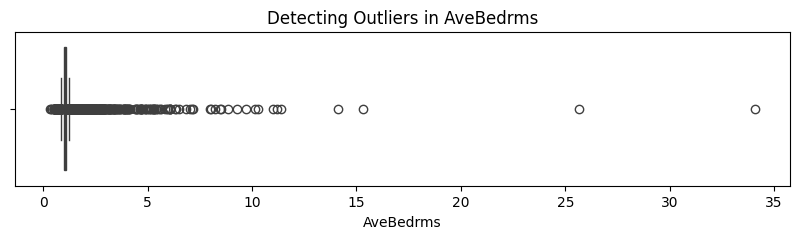

In [13]:
# Visualize the data with a boxplot
plt.figure(figsize=(10, 2)) # 10 inches wide and 2 inches tall
sns.boxplot(x=df[new_column])
plt.title(f"Detecting Outliers in {new_column}")
plt.show()

In [14]:
# finding the outliers in the new column
outliers = df[(df[new_column] > upper_bound) | (df[new_column] < lower_bound)]
print(f"Number of outliers in {new_column}: {len(outliers)}")
print(f"Total number of rows in the dataset: {len(df)}")

Number of outliers in AveBedrms: 1424
Total number of rows in the dataset: 20640


In [15]:
# Filter the DataFrame to remove outliers
df_no_outliers = df[(df[new_column] >= lower_bound) & (df[new_column] <= upper_bound)]
print(f"Shape before removing outliers: {df.shape}")
print(f"Shape after removing outliers: {df_no_outliers.shape}")

Shape before removing outliers: (20640, 8)
Shape after removing outliers: (19216, 8)


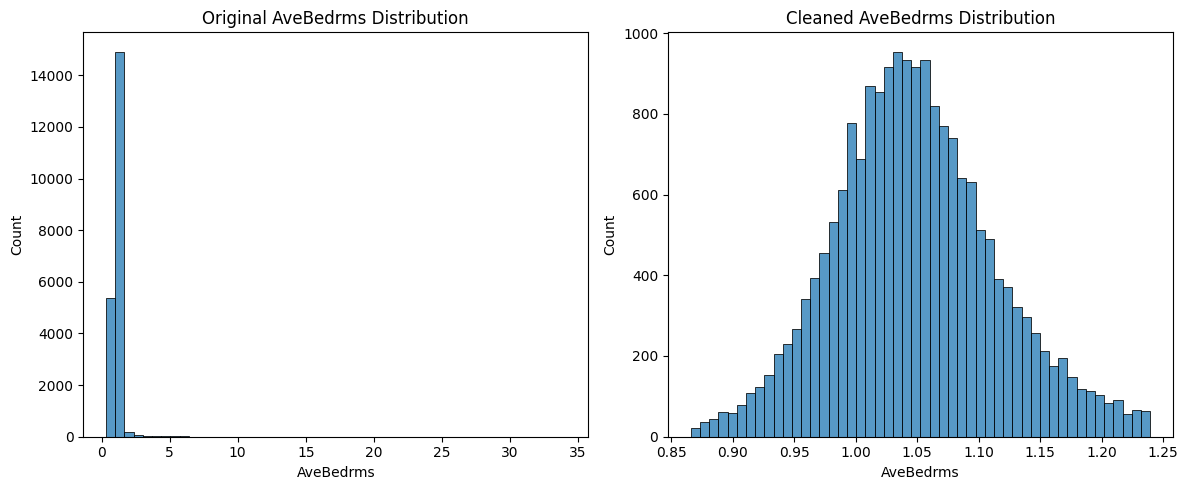

In [ ]:
# Compare the distribution of the original and cleaned datasets for the new column
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df[new_column], bins=50, ax = ax[0])
sns.histplot(df_no_outliers[new_column], bins= 50, ax = ax[1])
ax[0].set_title(f"Original {new_column} Distribution")
ax[1].set_title(f"Cleaned {new_column} Distribution")
plt.tight_layout()
plt.show()